# Synthetic Data Generation Example

In [1]:
import torch
from gen_srs_public.Data.basis_functions import BasisGeneratorConfig, BasisSetConfig
from gen_srs_public.Data.generate_time_series import generate_shocks, ShockGenerationConfig
from gen_srs_public.Plotting.plot import plot_shock_examples

1) Generate Synthetic Shock Data time series each 9000 elements long. Default basis are: "wavelet" and "decayed_sine".

In [2]:
n_shocks = 100
sample_rate = 32_768
ts_length = 9_000
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# Settings shared by every basis generator.
generator_config = BasisGeneratorConfig(
    device=device,
    ts_length=ts_length,
    sample_rate=sample_rate,
    amp_range=(0.25, 10.0),
    noise_std_range=(0.005, 0.05),
    fixed_noise_std=False,
    noise_device="cpu",  # Use "model" for faster device-side noise generation.
)

# Basis-specific settings are resolved before generate_shocks() is called.
default_basis_config = BasisSetConfig(
    generator=generator_config,
    names=("morlet_wavelet", "decayed_sine"),
    options={
        "morlet_wavelet": {
            "freq_range": (10, 4_096),
            "damp_range": (0.01, 10.0),
        },
        "decayed_sine": {
            "freq_range": (10, 4_096),
            "decay_range": (2.0, 100.0),
        },
    },
)

shock_config = ShockGenerationConfig(num_shocks=n_shocks)

Print the class and size and type of *y*

In [4]:
x = generate_shocks(generation_config=shock_config, basis_config=default_basis_config)

print(f"Synthetic shock container type: {type(x)}")
print(f"Synthetic shock tensor dtype: {x.shocks.dtype}")
print(f"Synthetic shock tensor shape: {x.shocks.shape}")

Generating time series: 100%|##########| 9.00/9.00 [00:00<00:00, 89.7batch/s]
Synthetic shock container type: <class 'gen_srs_public.Data.generate_time_series.ShockGenerationResult'>
Synthetic shock tensor dtype: torch.float32
Synthetic shock tensor shape: torch.Size([100, 9000])


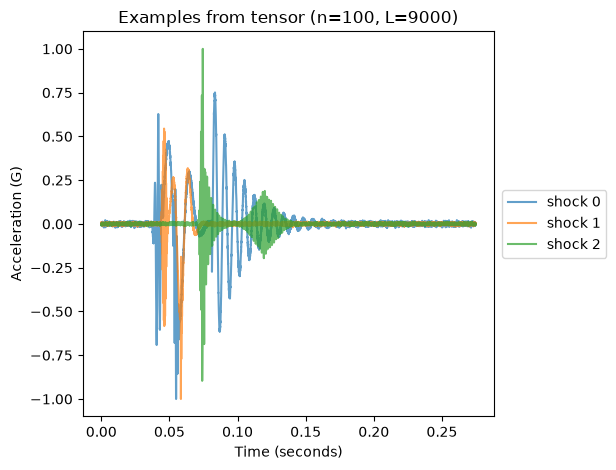

In [5]:
plot_shock_examples(x.shocks, sample_rate, k=3)

2. Generate Data with custom basis functions

In [6]:
custom_basis_config = BasisSetConfig(
    generator=generator_config,
    names=("morlet_wavelet", "sawtooth", "decayed_sine", "rbf"),
    options={
        "morlet_wavelet": {
            "freq_range": (10, 4_096),
            "damp_range": (0.01, 10.0),
        },
        "sawtooth": {},
        "decayed_sine": {
            "freq_range": (10, 4_096),
            "decay_range": (2.0, 100.0),
        },
        "rbf": {
            "frac_range": (1.5, 25.0),
            "decay_frac": 0.01,
        },
    },
)


In [7]:
y_all_basis = generate_shocks(generation_config=shock_config, basis_config=custom_basis_config)  # Shape: [N, L]

Generating time series:   0%|          | 0.00/9.00 [00:00<?, ?batch/s]

Generating time series: 12.0batch [00:00, 172batch/s]                 


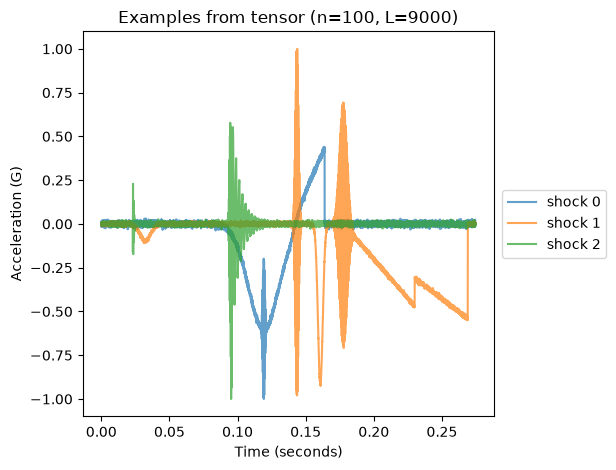

In [8]:
plot_shock_examples(y_all_basis.shocks, sample_rate, k=3)